# Modulo 34 - Regressao Polinomial
## Precificacao de Imoveis

### Contexto

O mercado imobiliario e influenciado por um conjunto de variaveis que afetam diretamente o valor de um imovel, seja para venda ou locacao. Entre esses fatores estao metragem, valor do condominio, numero de quartos, numero de banheiros e outras caracteristicas associadas a conforto, funcionalidade e padrao do imovel. Em geral, imoveis maiores e com melhor infraestrutura tendem a apresentar precos mais elevados.

### Objetivo

Desenvolver um modelo de regressao polinomial para prever o preco de imoveis, variando o grau do polinomio e comparando os resultados obtidos.

### Etapas da atividade
1. Importacao de bibliotecas, carregamento e separacao dos dados.
2. Modelagem polinomial.
3. Avaliacao dos resultados.
4. Revisao dos conceitos de regularizacao.

## 1. Importacao de Bibliotecas, Carregamento e Separacao dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Leitura dos dados
df = pd.read_csv("../../Base de Dados/ALUGUEL_MOD12.csv", delimiter=';')
df = df.rename(columns={"N_banheiros": "N_Banheiros"})
df.head()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_Banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0


## 2. Modelagem

Nesta etapa, definimos funcoes auxiliares para ajustar modelos polinomiais de diferentes graus, calcular metricas e, quando necessario, visualizar a curva ajustada sobre os dados observados. Com isso, evitamos repeticao de codigo e mantemos a analise mais organizada.

In [2]:
def build_prediction_grid(X, points=100):
    """Cria uma grade ordenada para visualizacao da curva ajustada."""
    feature_name = X.columns[0]
    values = np.linspace(X[feature_name].min(), X[feature_name].max(), points)
    return pd.DataFrame({feature_name: values})


def poly_fit(X, y, degree, show=False, scatter=False, line_color="navy"):
    """Ajusta regressao polinomial, calcula metricas e opcionalmente plota o ajuste."""
    feature_name = X.columns[0]
    poly_features = PolynomialFeatures(degree=degree)
    X_poly = poly_features.fit_transform(X)

    x_train, x_test, y_train, y_test = train_test_split(
        X_poly, y, test_size=0.2, random_state=0
    )

    model = LinearRegression()
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    if show:
        x_grid = build_prediction_grid(X)
        x_grid_poly = poly_features.transform(x_grid)
        y_grid_pred = model.predict(x_grid_poly)

        if scatter:
            plt.scatter(
                X[feature_name], y, color="red", alpha=0.5, label="Dados reais"
            )

        plt.plot(
            x_grid[feature_name],
            y_grid_pred,
            color=line_color,
            label=f"Polinomial grau {degree} | R2={r2:.3f}"
        )
        plt.xlabel(feature_name)
        plt.ylabel("Valor do Aluguel")
        plt.title("Regressoes Polinomiais por Grau")
        plt.legend()

    return {
        "grau": degree,
        "r2": r2,
        "mse": mse,
        "modelo": model,
    }


def compare_polynomial_degrees(X, y, degrees, plotted_degrees=None):
    """Avalia varios graus polinomiais e retorna metricas e modelos."""
    plotted_degrees = plotted_degrees or []
    color_map = {1: "black", 2: "royalblue", 4: "darkorange", 5: "forestgreen", 6: "crimson"}
    results = []
    models = {}

    for degree in degrees:
        result = poly_fit(
            X,
            y,
            degree=degree,
            show=degree in plotted_degrees,
            scatter=degree == min(plotted_degrees) if plotted_degrees else False,
            line_color=color_map.get(degree, "navy"),
        )
        results.append({
            "Grau do Polinomio": result["grau"],
            "R2": result["r2"],
            "MSE": result["mse"],
        })
        models[degree] = result["modelo"]

    return pd.DataFrame(results), models

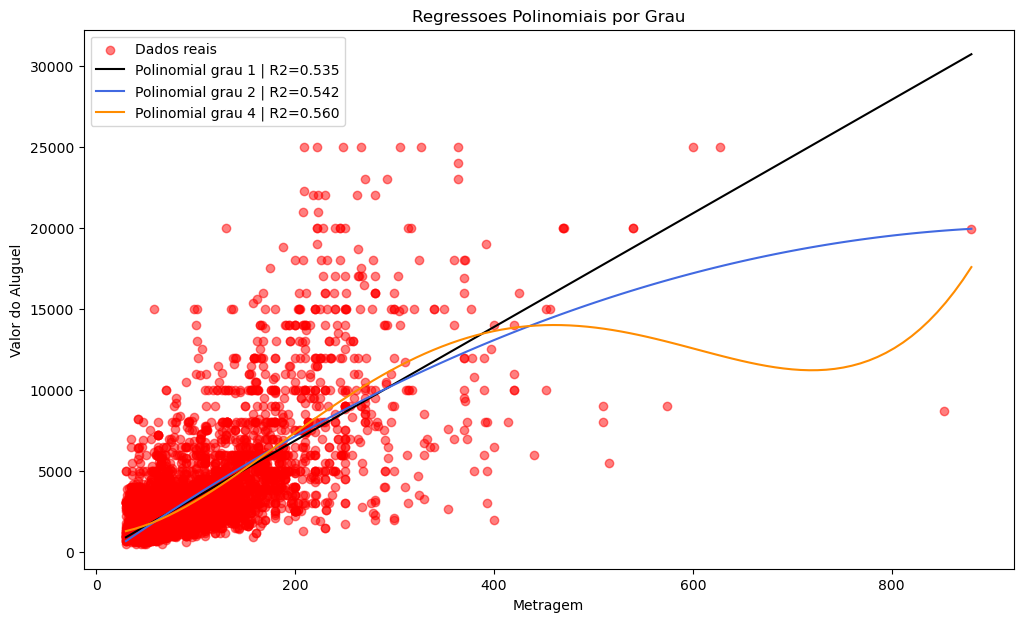

,Grau do Polinomio,R2,MSE
0,1,0.534934,4.310809e+06
1,2,0.542347,4.242097e+06
2,4,0.559578,4.082376e+06
3,5,0.557066,4.105663e+06
4,6,0.561124,4.068045e+06


In [3]:
# Separacao das variaveis
y = df["Valor_Aluguel"]
X = df[["Metragem"]]

degrees = [1, 2, 4, 5, 6]
plotted_degrees = [1, 2, 4]

plt.figure(figsize=(12, 7))
results_df, models = compare_polynomial_degrees(
    X, y, degrees=degrees, plotted_degrees=plotted_degrees
    )
plt.show()

display(results_df)

## 3. Resultados dos Ajustes Polinomiais

A tabela abaixo resume o desempenho dos modelos avaliados.


| Grau do Polinomio | R2    | MSE            |
|:------------------|------:|---------------:|
| 1 (linear)        | 0.535 | 4310808.92     |
| 2 (quadratico)    | 0.542 | 4242097.01     |
| 4                 | 0.560 | 4082376.36     |
| 5                 | 0.557 | 4105662.66     |
| 6                 | 0.561 | 4068045.36     |

**Tabela:** Ajustes polinomiais.

Considerando apenas a variavel metragem, os modelos de grau 2 e 4 apresentaram melhora em relacao ao ajuste linear, com vantagem discreta para o grau 4. O MSE tambem foi menor nesse caso, indicando um ajuste ligeiramente melhor.

Por outro lado, os graus 5 e 6 nao trouxeram ganhos consistentes. Embora haja variacoes pequenas no R2, elas nao compensam o aumento de complexidade do modelo. Em termos praticos, isso sugere que graus mais altos tendem a aumentar o risco de overfitting sem entregar melhoria relevante na capacidade preditiva.

## 4. Ridge, Lasso e Elastic Net

Ridge, Lasso e Elastic Net sao tecnicas de regularizacao usadas para melhorar a generalizacao de modelos de regressao e reduzir o risco de overfitting.

Em problemas classicos de regressao, a presenca de multicolinearidade entre variaveis explicativas pode tornar a solucao instavel e aumentar a variancia dos coeficientes. Nesses cenarios, a regularizacao ajuda a controlar a complexidade do modelo.

A **Ridge** aplica uma penalizacao L2, reduzindo a magnitude dos coeficientes sem zerar variaveis. Sua formulacao pode ser representada por:
$$
\min \left\|Ax-b\right\|_2^2 + \lambda_2 \left\|x\right\|_2^2
$$
Essa abordagem e util quando ha muitos preditores correlacionados e se deseja maior estabilidade sem descartar informacao.

A **Lasso** aplica uma penalizacao L1:
$$
\min \left\|Ax-b\right\|_2^2 + \lambda_1 \left\|x\right\|_1
$$
Como a norma L1 favorece coeficientes exatamente nulos, ela tambem funciona como metodo de selecao de variaveis, eliminando colunas pouco relevantes para o ajuste.

O **Elastic Net** combina as penalizacoes L1 e L2:
$$
\min \left\|Ax-b\right\|_2^2 + \lambda_1 \left\|x\right\|_1 + \lambda_2 \left\|x\right\|_2^2
$$
Essa combinacao preserva a capacidade de selecao de variaveis do Lasso e, ao mesmo tempo, melhora a estabilidade em bases com alta correlacao entre features, como ocorre em muitos problemas reais.